In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
import sys
sys.path.insert(0, '/Users/bryan.carroll/Library/CloudStorage/GoogleDrive-bryan.carroll@wise.com/My Drive/BryWise/AI')
import wise_colours



In [5]:
# Load the data
full_data = pd.read_csv('Business + CES and Contacts_2026-06-04-1616.csv', low_memory=False)

# Deduplicate survey responses: keep only the first survey per profile
first_survey = full_data.groupby('PROFILE_ID')['SURVEY_DATE'].transform('min')
full_data = full_data[full_data['SURVEY_DATE'] == first_survey]

# Time to first transfer in days
full_data['time_to_first_transfer'] = (
    pd.to_datetime(full_data['TRANSACTION_DATE']) - pd.to_datetime(full_data['SURVEY_DATE'])
) / pd.Timedelta(days=1)

# Aggregate transaction-level data to per-user summary (one row per profile)
txn_agg = full_data.groupby('PROFILE_ID').agg(
    CES_SCORE=('CES_SCORE', 'first'),
    CES_COMMENT=('CES_COMMENT', 'first'),
    SURVEY_DATE=('SURVEY_DATE', 'first'),
    PLATFORM=('PLATFORM', 'first'),
    VERIFICATION_START_TS=('VERIFICATION_START_TS', 'first'),
    # Support contacts
    HAD_KYC_CONTACT=('HAD_KYC_CONTACT', 'first'),
    KYC_CONTACT_COUNT=('KYC_CONTACT_COUNT', 'first'),
    FIRST_KYC_CONTACT_TS=('FIRST_KYC_CONTACT_TS', 'first'),
    LAST_KYC_CONTACT_TS=('LAST_KYC_CONTACT_TS', 'first'),
    # Transactions
    first_transaction_date=('TRANSACTION_DATE', 'min'),
    first_transaction_gbp=('INVOICE_AMOUNT_GBP', 'first'),
    send_count=('TRANSFER_ID', 'nunique'),
    send_value_gbp=('INVOICE_AMOUNT_GBP', 'sum')
).reset_index()

# Recalculate time to first transfer at profile level
txn_agg['time_to_first_transfer'] = (
    pd.to_datetime(txn_agg['first_transaction_date']) - pd.to_datetime(txn_agg['SURVEY_DATE'])
) / pd.Timedelta(days=1)

# df = users who converted (have at least one transaction post-survey)
df = txn_agg[txn_agg['first_transaction_date'].notna()].copy()
df['SURVEY_MONTH'] = pd.to_datetime(df['SURVEY_DATE']).dt.to_period('M')

# Check shape
print(f"Total profiles: {txn_agg['PROFILE_ID'].nunique():,}")
print(f"Platforms: {txn_agg['PLATFORM'].unique().tolist()}")
print(f"Platform counts (profiles):")
print(txn_agg['PLATFORM'].value_counts())
print(f"\nProfiles with transactions: {df['PROFILE_ID'].nunique():,}")
print(f"\n--- Contacts ---")
print(f"Had KYC contact: {txn_agg['HAD_KYC_CONTACT'].value_counts().to_dict()}")
print(f"KYC contact count (mean, contacted only): {txn_agg[txn_agg['HAD_KYC_CONTACT']==1]['KYC_CONTACT_COUNT'].mean():.2f}")
print(f"\n--- CES by contact status ---")
print(f"Mean CES (contacted):     {txn_agg[txn_agg['HAD_KYC_CONTACT']==1]['CES_SCORE'].mean():.2f}")
print(f"Mean CES (not contacted): {txn_agg[txn_agg['HAD_KYC_CONTACT']==0]['CES_SCORE'].mean():.2f}")

Total profiles: 11,920
Platforms: ['MOBILE_WEB', 'WEB']
Platform counts (profiles):
PLATFORM
WEB           9263
MOBILE_WEB    2657
Name: count, dtype: int64

Profiles with transactions: 9,510

--- Contacts ---
Had KYC contact: {0: 5960, 1: 5960}
KYC contact count (mean, contacted only): 1.29

--- CES by contact status ---
Mean CES (contacted):     5.46
Mean CES (not contacted): 5.67


In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

def fit_count_model(formula, data, label=""):
    """Try NegBin first; fall back to Poisson with robust SEs if NegBin fails."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            m = smf.negativebinomial(formula, data=data).fit(maxiter=1000, disp=False)
            if not m.mle_retvals['converged'] or np.any(np.isnan(m.bse)):
                raise RuntimeError("NegBin did not produce valid estimates")
            return m, 'NegBin'
        except (RuntimeError, np.linalg.LinAlgError, ValueError):
            m = smf.poisson(formula, data=data).fit(maxiter=1000, disp=False, cov_type='HC0')
            return m, 'Poisson (robust SE)'

# --- FOLLOW-ON TRANSFER COUNT (Negative Binomial) ---
df_reg = df.copy()
df_reg['followon_count'] = df_reg['send_count'] - 1
df_reg = df_reg[df_reg['followon_count'] >= 0]

p95 = df_reg['followon_count'].quantile(0.95)
df_reg['followon_count_w'] = df_reg['followon_count'].clip(upper=p95)

model_count, model_type = fit_count_model(
    'followon_count_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT',
    data=df_reg
)

print("=" * 70)
print("NEGATIVE BINOMIAL: Follow-On Transfer COUNT ~ CES + Platform + Contact")
print("=" * 70)
print(f"Model type: {model_type} (n={len(df_reg):,}, followon_count winsorized at p95={p95:.0f})")
print(f"\n{'Parameter':<30} {'Coef':>8} {'Rate Ratio':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 70)
for p_name in ['CES_SCORE', 'HAD_KYC_CONTACT'] + [k for k in model_count.params.index if 'PLATFORM' in k]:
    coef = model_count.params[p_name]
    rr = np.exp(coef)
    pval = model_count.pvalues[p_name]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {p_name:<28} {coef:>8.4f} {rr:>12.3f} {pval:>10.4f} {sig:>4}")

print(f"\n→ Each +1 CES point is associated with {(np.exp(model_count.params['CES_SCORE'])-1)*100:+.1f}% more follow-on transfers")
print(f"→ Having a KYC contact - holding CES constant - is associated with {(np.exp(model_count.params['HAD_KYC_CONTACT'])-1)*100:+.1f}% change in follow-on transfers")

# --- FOLLOW-ON TRANSFER VALUE (Gamma GLM) ---
df_val = df.copy()
df_val['followon_value'] = df_val['send_value_gbp'] - df_val['first_transaction_gbp']
df_val = df_val[df_val['followon_value'] > 0]

p95_val = df_val['followon_value'].quantile(0.95)
df_val['followon_value_w'] = df_val['followon_value'].clip(upper=p95_val)

gamma_model = smf.glm(
    'followon_value_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT',
    data=df_val,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(f"\n{'=' * 70}")
print("GAMMA GLM (log-link): Follow-On Transfer VALUE ~ CES + Platform + Contact")
print("=" * 70)
print(f"n={len(df_val):,}, winsorized at p95=£{p95_val:,.0f}")
print(f"\n{'Parameter':<30} {'Coef':>8} {'Multiplier':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 70)
for p_name in ['CES_SCORE', 'HAD_KYC_CONTACT'] + [k for k in gamma_model.params.index if 'PLATFORM' in k]:
    coef = gamma_model.params[p_name]
    mult = np.exp(coef)
    pval = gamma_model.pvalues[p_name]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {p_name:<28} {coef:>8.4f} {mult:>12.3f} {pval:>10.4f} {sig:>4}")

print(f"\n→ Each +1 CES point is associated with {(np.exp(gamma_model.params['CES_SCORE'])-1)*100:+.1f}% more follow-on transfer value")
print(f"→ Having a KYC contact - holding CES constant - is associated with {(np.exp(gamma_model.params['HAD_KYC_CONTACT'])-1)*100:+.1f}% change in follow-on transfer value")

NEGATIVE BINOMIAL: Follow-On Transfer COUNT ~ CES + Platform + Contact
Model type: NegBin (n=9,409, followon_count winsorized at p95=336)

Parameter                          Coef   Rate Ratio    p-value  Sig
----------------------------------------------------------------------
  CES_SCORE                      0.0766        1.080     0.0000  ***
  HAD_KYC_CONTACT                0.2655        1.304     0.0000  ***
  C(PLATFORM)[T.WEB]             0.0774        1.080     0.0424    *

→ Each +1 CES point is associated with +8.0% more follow-on transfers
→ Having a KYC contact - holding CES constant - is associated with +30.4% change in follow-on transfers

GAMMA GLM (log-link): Follow-On Transfer VALUE ~ CES + Platform + Contact
n=9,034, winsorized at p95=£1,063,331

Parameter                          Coef   Multiplier    p-value  Sig
----------------------------------------------------------------------
  CES_SCORE                      0.0900        1.094     0.0000  ***
  HAD_KYC_CONTAC

In [10]:
# Interaction test: does the CES → follow-on transfer relationship differ by contact status?
df_int = df.copy()
df_int['followon_count'] = df_int['send_count'] - 1
df_int = df_int[df_int['followon_count'] >= 0]

p95 = df_int['followon_count'].quantile(0.95)
df_int['followon_count_w'] = df_int['followon_count'].clip(upper=p95)

model_interaction, int_model_type = fit_count_model(
    'followon_count_w ~ CES_SCORE * HAD_KYC_CONTACT + C(PLATFORM)',
    data=df_int
)

print("=" * 70)
print("INTERACTION MODEL: CES × KYC Contact → Follow-On Transfers")
print("=" * 70)
print(f"Model type: {int_model_type} (n={len(df_int):,})")
print(f"\n{'Parameter':<35} {'Coef':>8} {'Rate Ratio':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 75)
for p_name in ['Intercept', 'CES_SCORE', 'HAD_KYC_CONTACT', 'CES_SCORE:HAD_KYC_CONTACT'] + [k for k in model_interaction.params.index if 'PLATFORM' in k]:
    if p_name in model_interaction.params.index:
        coef = model_interaction.params[p_name]
        rr = np.exp(coef)
        pval = model_interaction.pvalues[p_name]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {p_name:<33} {coef:>8.4f} {rr:>12.3f} {pval:>10.4f} {sig:>4}")

# Interpretation
int_p = model_interaction.pvalues.get('CES_SCORE:HAD_KYC_CONTACT', 1)
ces_coef = model_interaction.params['CES_SCORE']
int_coef = model_interaction.params.get('CES_SCORE:HAD_KYC_CONTACT', 0)

print(f"\n--- Stratified CES effect ---")
print(f"  Not contacted: +{(np.exp(ces_coef)-1)*100:.1f}% per CES point")
print(f"  Contacted:     +{(np.exp(ces_coef + int_coef)-1)*100:.1f}% per CES point")

print(f"\n--- Interpretation ---")
if int_p < 0.05:
    if int_coef > 0:
        print(f"  Interaction is SIGNIFICANT (p={int_p:.4f}): CES has a STRONGER effect for contacted users.")
        print(f"  Users who contacted support and still rated high are especially likely to transact heavily.")
    else:
        print(f"  Interaction is SIGNIFICANT (p={int_p:.4f}): CES has a WEAKER effect for contacted users.")
        print(f"  For contacted users, the experience-to-outcome link is attenuated (intent dominates).")
else:
    print(f"  Interaction is NOT significant (p={int_p:.4f}): the CES slope is similar for both groups.")
    print(f"  Contact status shifts the baseline (intent confound) but doesn't moderate how CES affects outcomes.")

INTERACTION MODEL: CES × KYC Contact → Follow-On Transfers
Model type: NegBin (n=9,409)

Parameter                               Coef   Rate Ratio    p-value  Sig
---------------------------------------------------------------------------
  Intercept                           3.3270       27.856     0.0000  ***
  CES_SCORE                           0.0839        1.088     0.0000  ***
  HAD_KYC_CONTACT                     0.3361        1.399     0.0006  ***
  CES_SCORE:HAD_KYC_CONTACT          -0.0123        0.988     0.4444   ns
  C(PLATFORM)[T.WEB]                  0.0768        1.080     0.0441    *

--- Stratified CES effect ---
  Not contacted: +8.8% per CES point
  Contacted:     +7.4% per CES point

--- Interpretation ---
  Interaction is NOT significant (p=0.4444): the CES slope is similar for both groups.
  Contact status shifts the baseline (intent confound) but doesn't moderate how CES affects outcomes.


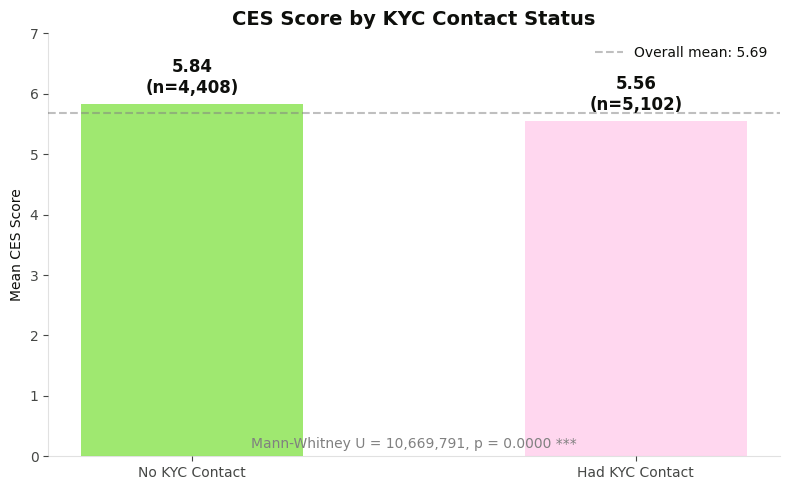


Contacted users report significantly lower CES (worse experience).
  No contact:  M=5.84, Mdn=7
  Had contact: M=5.56, Mdn=7
  Difference:  0.28 points


In [ ]:
# CES Score by Contact Status — mean comparison with significance test
from scipy.stats import mannwhitneyu

contacted = df[df['HAD_KYC_CONTACT'] == 1]['CES_SCORE']
not_contacted = df[df['HAD_KYC_CONTACT'] == 0]['CES_SCORE']

stat, p = mannwhitneyu(contacted, not_contacted, alternative='two-sided')

fig, ax = plt.subplots(figsize=(8, 5))

means = [not_contacted.mean(), contacted.mean()]
labels = ['No KYC Contact', 'Had KYC Contact']
colors = [wise_colours.BRIGHT_GREEN, wise_colours.BRIGHT_PINK]

bars = ax.bar(labels, means, color=colors, width=0.5)

for bar, mean, n in zip(bars, means, [len(not_contacted), len(contacted)]):
    ax.annotate(f"{mean:.2f}\n(n={n:,})", 
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylabel('Mean CES Score')
ax.set_ylim(0, 7)
ax.set_title('CES Score by KYC Contact Status')
ax.axhline(y=df['CES_SCORE'].mean(), color='grey', linestyle='--', alpha=0.5, label=f"Overall mean: {df['CES_SCORE'].mean():.2f}")
ax.legend()

sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.5, 0.02, f"Mann-Whitney U = {stat:,.0f}, p = {p:.4f} {sig}", 
        transform=ax.transAxes, ha='center', fontsize=10, color='grey')

plt.tight_layout()
plt.show()

print(f"\nContacted users report stat sig lower CES (worse experience).")
print(f"  No contact:  M={not_contacted.mean():.2f}, Mdn={not_contacted.median():.0f}")
print(f"  Had contact: M={contacted.mean():.2f}, Mdn={contacted.median():.0f}")
print(f"  Difference:  {not_contacted.mean() - contacted.mean():.2f} points")

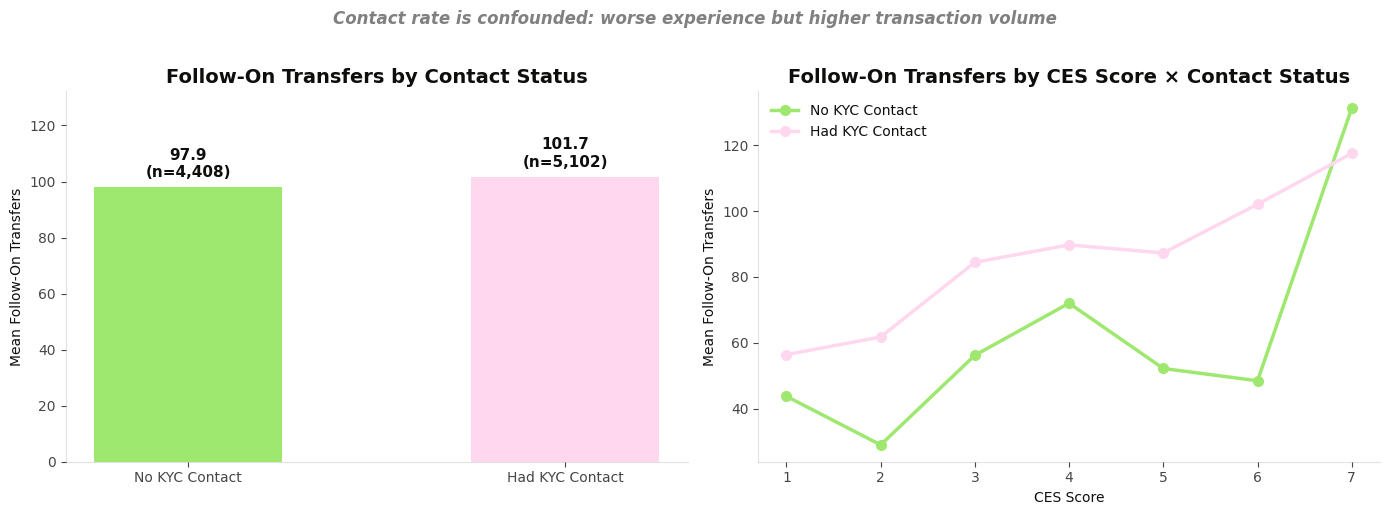

Left: Contacted users make MORE follow-on transfers despite worse CES.
Right: CES still predicts outcomes in both groups, but the contacted baseline is shifted up.
→ Contact captures intent/motivation, not just experience quality.


In [12]:
# The Paradox: contacted users have worse experience BUT more follow-on transfers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: mean follow-on transfers by contact status ---
ax = axes[0]
contact_means = df.groupby('HAD_KYC_CONTACT')['send_count'].mean()
labels = ['No KYC Contact', 'Had KYC Contact']
colors = [wise_colours.BRIGHT_GREEN, wise_colours.BRIGHT_PINK]

bars = ax.bar(labels, [contact_means[0], contact_means[1]], color=colors, width=0.5)

for bar, val, n in zip(bars, [contact_means[0], contact_means[1]], 
                         [len(df[df['HAD_KYC_CONTACT']==0]), len(df[df['HAD_KYC_CONTACT']==1])]):
    ax.annotate(f"{val:.1f}\n(n={n:,})", 
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylabel('Mean Follow-On Transfers')
ax.set_title('Follow-On Transfers by Contact Status')
ax.set_ylim(0, contact_means.max() * 1.3)

# --- Right panel: follow-on transfers by CES, stratified by contact status ---
ax = axes[1]

ces_contact = df.groupby(['CES_SCORE', 'HAD_KYC_CONTACT'])['send_count'].mean().reset_index()

for contact_val, color, label in [(0, wise_colours.BRIGHT_GREEN, 'No KYC Contact'), 
                                   (1, wise_colours.BRIGHT_PINK, 'Had KYC Contact')]:
    subset = ces_contact[ces_contact['HAD_KYC_CONTACT'] == contact_val]
    ax.plot(subset['CES_SCORE'], subset['send_count'], 
            color=color, marker='o', linewidth=2.5, markersize=7, label=label)

ax.set_xlabel('CES Score')
ax.set_ylabel('Mean Follow-On Transfers')
ax.set_title('Follow-On Transfers by CES Score × Contact Status')
ax.set_xticks(range(1, 8))
ax.legend()

fig.suptitle('Contact rate is confounded: worse experience but higher transaction volume', 
             fontsize=12, y=1.02, style='italic', color='grey')
plt.tight_layout()
plt.show()

print("Left: Contacted users make MORE follow-on transfers despite worse CES.")
print("Right: CES still predicts outcomes in both groups, but the contacted baseline is shifted up.")
print("→ Contact captures intent/motivation, not just experience quality.")

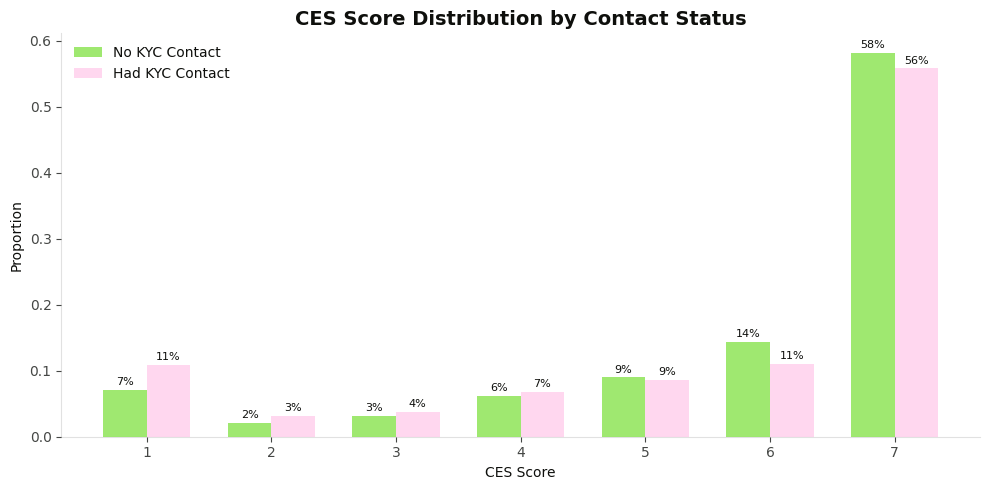

In [14]:
# CES distribution by contact status
fig, ax = plt.subplots(figsize=(10, 5))

scores = range(1, 8)
width = 0.35

contacted_dist = df[df['HAD_KYC_CONTACT'] == 1]['CES_SCORE'].value_counts(normalize=True).reindex(scores, fill_value=0)
not_contacted_dist = df[df['HAD_KYC_CONTACT'] == 0]['CES_SCORE'].value_counts(normalize=True).reindex(scores, fill_value=0)

x = np.arange(len(scores))
bars1 = ax.bar(x - width/2, not_contacted_dist.values, width, color=wise_colours.BRIGHT_GREEN, label='No KYC Contact')
bars2 = ax.bar(x + width/2, contacted_dist.values, width, color=wise_colours.BRIGHT_PINK, label='Had KYC Contact')

ax.set_xlabel('CES Score')
ax.set_ylabel('Proportion')
ax.set_title('CES Score Distribution by Contact Status')
ax.set_xticks(x)
ax.set_xticklabels(scores)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        if bar.get_height() > 0.01:
            ax.annotate(f"{bar.get_height():.0%}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

   HAD_KYC_CONTACT      mean  count
0                0  0.739597   5960
1                1  0.856040   5960


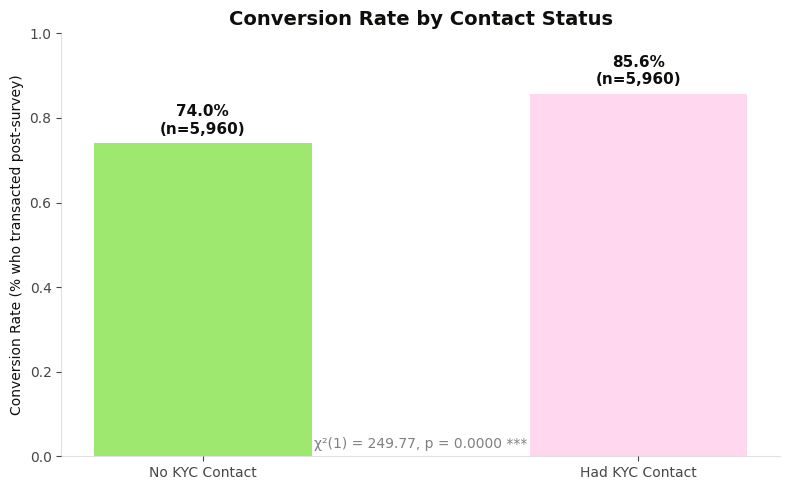


Conversion rate difference: +11.6%pp
Contacted users convert at a higher rate — further evidence of intent/motivation confound.


In [ ]:
# Conversion rate by contact status (did the user transact at all post-survey?)
txn_agg['converted'] = txn_agg['first_transaction_date'].notna().astype(int)

conv_by_contact = txn_agg.groupby('HAD_KYC_CONTACT')['converted'].agg(['mean', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

labels = ['No KYC Contact', 'Had KYC Contact']
colors = [wise_colours.BRIGHT_GREEN, wise_colours.BRIGHT_PINK]
rates = conv_by_contact['mean'].values
counts = conv_by_contact['count'].values

bars = ax.bar(labels, rates, color=colors, width=0.5)

for bar, rate, n in zip(bars, rates, counts):
    ax.annotate(f"{rate:.1%}\n(n={n:,})", 
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylabel('Conversion Rate (% who transacted post-survey)')
ax.set_title('Conversion Rate by Contact Status')
ax.set_ylim(0, 1)

# Chi-square test
ct = pd.crosstab(txn_agg['HAD_KYC_CONTACT'], txn_agg['converted'])
chi2, p, dof, _ = chi2_contingency(ct)
sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.5, 0.02, f"χ²({dof}) = {chi2:.2f}, p = {p:.4f} {sig}", 
        transform=ax.transAxes, ha='center', fontsize=10, color='grey')

plt.tight_layout()
plt.show()

print(f"\nConversion rate difference: {rates[1]-rates[0]:+.1%}pp")
print("Contacted users convert at a higher rate — further evidence of intent/motivation confound.")

Profiles with ≥2 transfers: 9,034
  Contacted:     4,881
  Not contacted: 4,153


/var/folders/1h/w4xhw7bx50xfvy_jpdv3p41h0000gp/T/ipykernel_42685/388653936.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_contact, labels=['No KYC Contact', 'Had KYC Contact'],


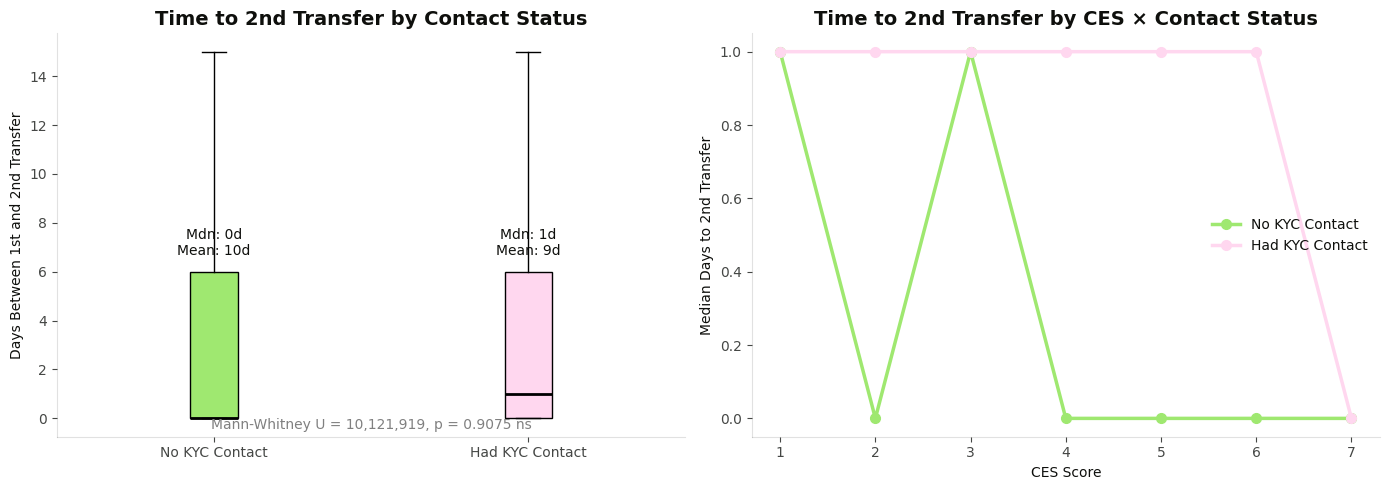


If contacted users return SLOWER, the bad experience creates hesitancy
even though intent eventually brings them back (volume confound).
If similar or faster, intent dominates completely — no hesitancy signal.


In [16]:
# Time to 2nd transfer by contact status
# Need to go back to the transaction-level data to get 1st and 2nd transfer dates per profile

txn_level = full_data[full_data['TRANSACTION_DATE'].notna()].copy()
txn_level['TRANSACTION_DATE'] = pd.to_datetime(txn_level['TRANSACTION_DATE'])
txn_level['SURVEY_DATE_dt'] = pd.to_datetime(txn_level['SURVEY_DATE'])

# Rank transactions per profile by date
txn_level = txn_level.sort_values(['PROFILE_ID', 'TRANSACTION_DATE'])
txn_level['txn_rank'] = txn_level.groupby('PROFILE_ID').cumcount() + 1

# Get 1st and 2nd transfer dates
first_txn = txn_level[txn_level['txn_rank'] == 1][['PROFILE_ID', 'TRANSACTION_DATE']].rename(columns={'TRANSACTION_DATE': 'first_txn_date'})
second_txn = txn_level[txn_level['txn_rank'] == 2][['PROFILE_ID', 'TRANSACTION_DATE']].rename(columns={'TRANSACTION_DATE': 'second_txn_date'})

repeat_df = first_txn.merge(second_txn, on='PROFILE_ID', how='inner')
repeat_df['days_to_2nd'] = (repeat_df['second_txn_date'] - repeat_df['first_txn_date']) / pd.Timedelta(days=1)

# Merge back contact status and CES
repeat_df = repeat_df.merge(
    df[['PROFILE_ID', 'HAD_KYC_CONTACT', 'CES_SCORE']],
    on='PROFILE_ID', how='inner'
)

print(f"Profiles with ≥2 transfers: {len(repeat_df):,}")
print(f"  Contacted:     {(repeat_df['HAD_KYC_CONTACT']==1).sum():,}")
print(f"  Not contacted: {(repeat_df['HAD_KYC_CONTACT']==0).sum():,}")

# --- Plot: time to 2nd transfer by contact status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot by contact status
ax = axes[0]
data_contact = [repeat_df[repeat_df['HAD_KYC_CONTACT']==0]['days_to_2nd'],
                repeat_df[repeat_df['HAD_KYC_CONTACT']==1]['days_to_2nd']]

bp = ax.boxplot(data_contact, labels=['No KYC Contact', 'Had KYC Contact'], 
                showfliers=False, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor(wise_colours.BRIGHT_GREEN)
bp['boxes'][1].set_facecolor(wise_colours.BRIGHT_PINK)

for i, d in enumerate(data_contact):
    ax.annotate(f"Mdn: {d.median():.0f}d\nMean: {d.mean():.0f}d", 
                (i+1, d.quantile(0.75)), ha='center', va='bottom', fontsize=10,
                xytext=(0, 10), textcoords='offset points')

ax.set_ylabel('Days Between 1st and 2nd Transfer')
ax.set_title('Time to 2nd Transfer by Contact Status')

stat, p = mannwhitneyu(data_contact[0], data_contact[1], alternative='two-sided')
sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.5, 0.02, f"Mann-Whitney U = {stat:,.0f}, p = {p:.4f} {sig}", 
        transform=ax.transAxes, ha='center', fontsize=10, color='grey')

# Right: time to 2nd transfer by CES, stratified by contact status
ax = axes[1]
ces_repeat = repeat_df.groupby(['CES_SCORE', 'HAD_KYC_CONTACT'])['days_to_2nd'].median().reset_index()

for contact_val, color, label in [(0, wise_colours.BRIGHT_GREEN, 'No KYC Contact'), 
                                   (1, wise_colours.BRIGHT_PINK, 'Had KYC Contact')]:
    subset = ces_repeat[ces_repeat['HAD_KYC_CONTACT'] == contact_val]
    ax.plot(subset['CES_SCORE'], subset['days_to_2nd'], 
            color=color, marker='o', linewidth=2.5, markersize=7, label=label)

ax.set_xlabel('CES Score')
ax.set_ylabel('Median Days to 2nd Transfer')
ax.set_title('Time to 2nd Transfer by CES × Contact Status')
ax.set_xticks(range(1, 8))
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nIf contacted users return SLOWER, the bad experience creates hesitancy")
print(f"even though intent eventually brings them back (volume confound).")
print(f"If similar or faster, intent dominates completely — no hesitancy signal.")

## Key Finding: Intent vs. Experience

**Intent determines *whether* users come back. Experience determines *how quickly*.**

Support seeking users have higher underlying intent (business need forces them to use Wise), so their total transfer volume ends up higher despite worse experience. Looking at contact rate confounds the experience with their intent, and intent overwhelms the signal. We can see the experience/friction signal through CES - reduced median CES (which then has reduced follow on transaction), and reduced tiem to second transfer. CES captures the **hesitancy**. CES captures this delay signal: as CES improves, the median gap to 2nd transfer collapses to zero regardless of contact status.

The CES=7 convergence is particularly telling — when the experience is excellent, it doesn't matter whether you had a contact or not. The hesitancy disappears. Contact only creates drag when paired with a mediocre or poor experience.

### Why contact rate fails as a proxy for user experience

1. Contact rate conflates intent with experience — high-intent users contact support *and* transact heavily, creating a spurious positive association
2. The true cost of poor experience isn't visible in volume (intent masks it) when looking at contact rate alone. You can see the difference in **time to return** and **mean,** which compounds over a customer lifetime
3. CES captures the friction dimension that contact rate cannot isolate while also providing signal on follow on behavior.

### Implication for measurement strategy

This analysis demonstrates that readily available behavioural signals (contact rate, transfer volume) are confounded and cannot serve as proxies for user experience. A direct, validated experience measure is required.